In [4]:
#Dataframe für die Bestimmung von m erstellen
import re
import pandas as pd
from pathlib import Path

#  Datei einlesen
txt_path = Path("Ergebnis aus Bestimmung von m")
lines = txt_path.read_text(encoding="utf-8", errors="ignore").splitlines()

# DataFrame parsen
rows = []

dataset = None
p_val = None
m_from = None
m_to = None

for line in lines:
    line = line.strip()
    if line == "":
        continue

    # 1) "Iris Datensatz"
    m = re.match(r"^(.*)\s+Datensatz$", line)
    if m:
        dataset = m.group(1).strip()
        continue

    # 2) "p =  1.3"
    m = re.match(r"^p\s*=\s*([0-9.]+)$", line)
    if m:
        p_val = float(m.group(1))
        continue

    # 3) "Vergleich m=5 und m=10"
    m = re.match(r"^Vergleich\s+m\s*=\s*(\d+)\s+und\s+m\s*=\s*(\d+)\s*$", line)
    if m:
        m_from = int(m.group(1))
        m_to = int(m.group(2))
        continue

    # 4) Danach kommt eine Zahl (Höhe der Änderung)
    if re.match(r"^[+-]?\d+(\.\d+)?([eE][+-]?\d+)?$", line):
        height = float(line)

        rows.append({
            "dataset": dataset,
            "p": p_val,
            "m_from": m_from,
            "m_to": m_to,
            "change": f"{m_from}→{m_to}",
            "height": height
        })

df = pd.DataFrame(rows)

# Sortieren
df = df.sort_values(["dataset", "p", "m_from", "m_to"]).reset_index(drop=True)

# CSV speichern
out_csv = Path("Bestimmung_m_changes.csv")
df.to_csv(out_csv, index=False)

print("Fertig! DataFrame gespeichert als:", out_csv)
print(df.head())

Fertig! DataFrame gespeichert als: Bestimmung_m_changes.csv
     dataset    p  m_from  m_to    change     height
0  Covertype  1.0       5    10      5→10  14.204677
1  Covertype  1.0      10    50     10→50   4.842969
2  Covertype  1.0      50   100    50→100   1.595472
3  Covertype  1.0     200   500   200→500   1.371639
4  Covertype  1.0     500  1000  500→1000   1.168732


In [5]:
#Plots für die Bestimmung von m
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("default")

# Schriftgrößen anpassen
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

# DataFrame einlesen
df = pd.read_csv("Bestimmung_m_changes.csv")

# Plots erstellen
out_dir = Path("Plots")
out_dir.mkdir(exist_ok=True)

for dataset_name in df["dataset"].unique():
    sub = df[df["dataset"] == dataset_name]

    # x-Reihenfolge festlegen (z.B. 5→10, 10→50, 50→100, ...)
    order = (sub[["m_from", "m_to", "change"]]
             .drop_duplicates()
             .sort_values(["m_from", "m_to"]))
    x_labels = order["change"].tolist()

    # 2 Panels nebeneinander
    fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

    # Für jedes p eine Linie
    for p_val in sorted(sub["p"].unique()):
        s2 = sub[sub["p"] == p_val].set_index("change").reindex(x_labels)
        y = s2["height"].values

        ax_lin.plot(x_labels, y, marker="o", label=f"p={p_val}")
        ax_log.plot(x_labels, y, marker="o", label=f"p={p_val}")

    # Linkes Panel: linear
    ax_lin.set_title("Linear")
    ax_lin.grid(True, linestyle="--", alpha=0.6)

    # Rechtes Panel: log
    ax_log.set_title("Log")
    ax_log.set_yscale("log")
    ax_log.grid(True, which="both", linestyle="--", alpha=0.6)

    # gemeinsame Legende (oben)
    handles, labels = ax_lin.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(5, len(labels)), bbox_to_anchor=(0.5, 0.98))

    # x labels besser lesbar
    for ax in (ax_lin, ax_log):
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle(f"{dataset_name}", y=1.04, fontsize=20)
    fig.supxlabel("Änderung von m_1 zu m_2", fontsize=16)
    fig.supylabel("Höhe der Änderungen", fontsize=16)
    fig.tight_layout()

    out_dir = Path("Plots") / "Plots_Bestimmung_m_zwei_Panels"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{dataset_name}_two_panels.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight", transparent=False)
    plt.close(fig)

    print("Gespeichert:", out_path)

Gespeichert: Plots\Plots_Bestimmung_m_zwei_Panels\Covertype_two_panels.png
Gespeichert: Plots\Plots_Bestimmung_m_zwei_Panels\Example2D_two_panels.png
Gespeichert: Plots\Plots_Bestimmung_m_zwei_Panels\Iris_two_panels.png
Gespeichert: Plots\Plots_Bestimmung_m_zwei_Panels\KDDCup_two_panels.png
Gespeichert: Plots\Plots_Bestimmung_m_zwei_Panels\Webspam_two_panels.png


In [6]:
# Wahrscheinlichkeitsverteilung der Methoden pro Datensatz in Dataframe speichern
import numpy as np
import pandas as pd
from pathlib import Path

# Laden der Methoden
from efficient_probit_regression.sampling import calculate_l2_lp_leverage_score, compute_leverage_scores, compute_random_evaluations_probabilities_v2, calculate_lewis_weights_exact, to_density

# Datensätze einlesen
%store -r Webspam
%store -r Iris
%store -r KDDCup
%store -r Covertype
%store -r Example2D

# Wahrscheinlichkeitsverteilung der vier Methoden für die Datensätze berechnen

# p festlegen
p = [1.0, 1.3, 1.5, 1.7, 2.0]

datasets = {
    "Webspam": Webspam,
    "Iris": Iris,
    "KDDCup": KDDCup,
    "Covertype": Covertype,
    "Example2D": Example2D,
}


def compute_all_distributions_for_p(X: np.ndarray, p_val: float, seed=2026, m_random=1000):
    # Liefert die 4 Dichten für einen Datensatz X und einen p-Wert.

    # 1) lp leverage score -> density
    lp_scores = compute_leverage_scores(X, p=p_val, fast_approx=False)
    lp_prob = to_density(lp_scores)

    # 2) Lewis weights -> density
    lewis_w = calculate_lewis_weights_exact(X, p=p_val)
    lewis_prob = to_density(lewis_w)

    # 3) Random evaluations probabilities
    rand_prob = compute_random_evaluations_probabilities_v2(X, m=m_random, p=p_val, rng=seed)

    # 4) l2+lp leverage score -> density
    _, l2lp_prob = calculate_l2_lp_leverage_score(X, p=p_val, fast_approx=False)

    return lp_prob, lewis_prob, rand_prob, l2lp_prob


rows = []

for ds_name, ds in datasets.items():
    X = ds.X
    n, d = X.shape

    for p_val in p:
        lp_prob, lewis_prob, rand_prob, l2lp_prob = compute_all_distributions_for_p(X, p_val)

        rows.append({
            "dataset": ds_name,
            "p": float(p_val),
            "prob_lp": lp_prob,
            "prob_lewis_weight": lewis_prob,
            "prob_random_evaluations_probabilities": rand_prob,
            "prob_l2_lp_leverage_score": l2lp_prob,
        })

df_probs = pd.DataFrame(rows)

out_dir = Path("Plots")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "probability_distributions.pkl"
df_probs.to_pickle(out_path)

print("Gespeichert:", out_path)

Gespeichert: Plots\probability_distributions.pkl


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from efficient_probit_regression.sampling import to_density
from efficient_probit_regression.total_variation_distance import total_variation_distance

# DataFrame laden
PICKLE_PATH = Path("Plots") / "probability_distributions.pkl"
df_probs = pd.read_pickle(PICKLE_PATH)

OUT_DIR = Path("Plots") / "BA_Comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

METHODS = [
    ("lp leverage score", "prob_lp"),
    ("Lewis weight", "prob_lewis_weight"),
    ("Random evaluations", "prob_random_evaluations_probabilities"),
    ("l2+lp leverage score", "prob_l2_lp_leverage_score"),
]

def topk_sorted_cumsum(prob):
    """Sortiert prob absteigend und gibt cumulative sums zurück."""
    s = np.sort(to_density(prob))[::-1]
    return np.cumsum(s)


def k_for_mass(cumsum, target):
    """Kleinstes k mit cumsum[k-1] >= target."""
    idx = np.searchsorted(cumsum, target, side="left")
    return int(min(idx + 1, len(cumsum)))


def tv_matrix_from_row(row):
    """4x4 TV-Matrix für eine Zeile (Datensatz,p) über METHODS."""
    cols = [m[1] for m in METHODS]
    probs = [to_density(row[c]) for c in cols]
    k = len(probs)
    tv = np.zeros((k, k), dtype=float)
    for i in range(k):
        for j in range(k):
            tv[i, j] = total_variation_distance(probs[i], probs[j])
    return tv

def compute_common_ks(df_probs, num_points=90):
    """
    Einheitliche k-Stützstellen (x-Achse) für alle Plots.
    Zusätzlich wird IMMER k=n_max hinzugefügt, damit Kurven bis zum Ende laufen.
    """
    # globales n bestimmen
    n_max = 0
    for _, row in df_probs.iterrows():
        n_max = max(n_max, len(to_density(row[METHODS[0][1]])))

    # log-spaced ks bis n_max
    ks = np.unique(np.round(np.logspace(0, np.log10(n_max), num_points)).astype(int))
    ks = ks[ks >= 1]
    ks = np.unique(np.concatenate([ks, np.array([n_max], dtype=int)]))

    return ks


def plot_topk_mass_curves_with_thresholds(
        row,
        ks,
        thresholds=(0.5, 0.9, 0.95),
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=200,
        annotate_ks=False
):
    """
    Top-k mass curves + horizontale Schwellenlinien + Marker.
    Gibt zusätzlich ein DataFrame mit k50/k90/k95 pro Methode zurück.
    """
    dataset = row["dataset"]
    p_val = row["p"]

    fig, ax = plt.subplots(figsize=(9, 5))
    summary = []

    for label, col in METHODS:
        c = topk_sorted_cumsum(row[col])
        n = len(c)
        ks_eff = ks[ks <= n]

        if len(ks_eff) == 0 or ks_eff[-1] != n:
            ks_eff = np.unique(np.concatenate([ks_eff, np.array([n], dtype=int)]))
        y = c[ks_eff - 1]

        ax.plot(ks_eff, y, linewidth=1.8, label=label)

        entry = {"dataset": dataset, "p": float(p_val), "method": label}
        for t in thresholds:
            entry[f"k{int(t * 100)}"] = k_for_mass(c, t)

        summary.append(entry)

        # Marker (und optional Text) für Schwellen
        for t in thresholds:
            k_t = entry[f"k{int(t * 100)}"]
            ax.scatter([k_t], [t], s=22)
            if annotate_ks:
                ax.text(k_t, t, f"  k={k_t}", va="center", fontsize=9)

    for t in thresholds:
        ax.axhline(t, linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_xscale("log")
    ax.set_ylim(0, 1.01)
    ax.set_title(f"{dataset} (p = {p_val})\nTop-k-Mass-Kurve")
    ax.set_xlabel("k (log)")
    ax.set_ylabel(r"$M(k)$")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
    ax.set_ylim(0.0, 1.02)  # etwas Luft über 1.0
    ax.set_yticks([0.0, 0.5, 0.9, 1.0])  # gut lesbar für k50/k90
    ax.set_yticklabels(["0", "0.5", "0.9", "1.0"])

    fig.tight_layout()

    if save:
        p_str = str(p_val).replace(".", "_")
        out_path = out_dir / f"TopK_{dataset}_p_{p_str}.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return pd.DataFrame(summary)


def generate_all_topk_plots_and_table(
        df_probs,
        save=True,
        show=False,
        thresholds=(0.5, 0.9, 0.95),
        num_points=90,
        annotate_ks=False,
        save_table=True,
        out_dir=OUT_DIR
):
    """
    Batch: pro Datensatz & p Top-k Plot erzeugen + k50/k90/k95 Tabelle sammeln.
    """
    ks = compute_common_ks(df_probs, num_points=num_points)
    all_summaries = []

    for dataset_name in df_probs["dataset"].unique():
        sub = df_probs[df_probs["dataset"] == dataset_name].sort_values("p")
        for _, row in sub.iterrows():
            df_sum = plot_topk_mass_curves_with_thresholds(
                row, ks=ks, thresholds=thresholds,
                save=save, show=show, annotate_ks=annotate_ks,
                out_dir=out_dir
            )
            all_summaries.append(df_sum)

    summary_df = pd.concat(all_summaries, ignore_index=True)

    if save_table:
        out_csv = out_dir / "TopK_thresholds_table.csv"
        summary_df.to_csv(out_csv, index=False)
        print("Tabelle gespeichert:", out_csv)

    return summary_df

# TV-Heatmaps mit konsistenter Farbschiene (vmin/vmax)

def compute_global_tv_vmax(df_probs, robust=False, quantile=0.95):
    """
    Bestimmt vmax für konsistente Skala.
    robust=False: globales Maximum über alle Off-diagonal Zellen
    robust=True : Quantil (z.B. 0.95) über alle Off-diagonal Zellen
    """
    vals = []
    for _, row in df_probs.iterrows():
        tv = tv_matrix_from_row(row)
        off = tv[~np.eye(tv.shape[0], dtype=bool)]
        vals.append(off)
    vals = np.concatenate(vals)

    if robust:
        return float(np.quantile(vals, quantile))
    return float(np.max(vals))


def plot_tv_heatmap(
        row,
        vmin=0.0,
        vmax=1.0,
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=200,
        annotate=True
):
    """
    4x4 TV Heatmap (eine pro Datensatz,p) mit fixem vmin/vmax.
    """
    dataset = row["dataset"]
    p_val = row["p"]

    labels = [m[0] for m in METHODS]
    tv = tv_matrix_from_row(row)
    k = tv.shape[0]

    fig, ax = plt.subplots(figsize=(7.3, 6.2))
    im = ax.imshow(tv, aspect="equal", vmin=vmin, vmax=vmax)

    ax.set_title(f"{dataset} (p = {p_val})\nTVD")
    ax.set_xticks(range(k))
    ax.set_yticks(range(k))
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_yticklabels(labels)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("TVD")

    if annotate:
        for i in range(k):
            for j in range(k):
                ax.text(j, i, f"{tv[i, j]:.3f}", ha="center", va="center")

    ax.set_xlabel("Method")
    ax.set_ylabel("Method")
    fig.tight_layout()

    if save:
        p_str = str(p_val).replace(".", "_")
        out_path = out_dir / f"TVD_Heatmap_{dataset}_p_{p_str}.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)


def generate_all_tv_heatmaps(
        df_probs,
        save=True,
        show=False,
        robust_vmax=False,
        quantile=0.95,
        annotate=True,
        out_dir=OUT_DIR
):
    """
    pro Datensatz & p TV Heatmap erzeugen, alle mit gleicher Skala.
    """
    vmax = compute_global_tv_vmax(df_probs, robust=robust_vmax, quantile=quantile)
    vmin = 0.0
    print(f"TV Heatmap scale fixed: vmin={vmin}, vmax={vmax:.4f} "
          f"{'(robust)' if robust_vmax else '(global max)'}")

    for dataset_name in df_probs["dataset"].unique():
        sub = df_probs[df_probs["dataset"] == dataset_name].sort_values("p")
        for _, row in sub.iterrows():
            plot_tv_heatmap(
                row, vmin=vmin, vmax=vmax,
                save=save, show=show, annotate=annotate,
                out_dir=out_dir
            )

def plot_compact_topk_figure_for_dataset(
        df_probs,
        dataset_name,
        p_values=None,
        thresholds=(0.5, 0.9),
        num_points=90,
        save=False,
        show=True,
        out_dir=OUT_DIR,
        dpi=300,
):
    if p_values is None:
        p_values = sorted(df_probs[df_probs["dataset"] == dataset_name]["p"].unique().tolist())

    # gemeinsame ks über alle Daten
    ks = compute_common_ks(df_probs, num_points=num_points)

    sub = df_probs[df_probs["dataset"] == dataset_name].copy()
    sub = sub[sub["p"].isin(p_values)].sort_values("p")

    n_panels = len(p_values)

    # Layout
    nrows, ncols = 1, n_panels
    figsize = (3.6 * n_panels, 3.2)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=True)
    if n_panels == 1:
        axes = [axes]
    else:
        axes = axes.ravel()

    # Für globale Legende
    global_handles = None
    global_labels = None

    for idx, (_, row) in enumerate(sub.iterrows()):
        ax = axes[idx]
        p_val = row["p"]

        handles = []
        labels = []

        for label, col in METHODS:
            c = topk_sorted_cumsum(row[col])
            n = len(c)

            ks_eff = ks[ks <= n]

            if len(ks_eff) == 0 or ks_eff[-1] != n:
                ks_eff = np.unique(np.concatenate([ks_eff, np.array([n], dtype=int)]))

            y = c[ks_eff - 1]
            h, = ax.plot(ks_eff, y, linewidth=1.8, label=label)
            handles.append(h)
            labels.append(label)

        # Schwellenlinien (nur major, dezent)
        for t in thresholds:
            ax.axhline(t, linestyle="--", linewidth=1.0, alpha=0.45)

        ax.set_xscale("log")
        ax.set_title(f"p = {p_val}", fontsize=12)

        # Weniger visuelles Rauschen:
        ax.grid(True, which="major", linestyle="--", alpha=0.25)
        ax.grid(False, which="minor")
        ax.minorticks_off()

        ax.set_ylim(0.0, 1.02)
        ax.set_yticks([0.0, 0.5, 0.9, 1.0])

        # y tick labels nur links (nur erstes Panel)
        ax.tick_params(labelleft=(idx == 0))

        if global_handles is None:
            global_handles = handles
            global_labels = labels

    # Achsenbeschriftungen
    axes[0].set_ylabel(r"$M(k)$")
    for ax in axes:
        ax.set_xlabel("k (log)")

    fig.suptitle(f"{dataset_name}", fontsize=16, y=0.98)

    # Globale Legende
    fig.legend(
        global_handles, global_labels,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.9)
    )

    fig.tight_layout(rect=[0.02, 0.02, 0.98, 0.92])

    if save:
        out_path = out_dir / f"CompactTopK_{dataset_name}.png"
        fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
        print("Gespeichert:", out_path)

    if show:
        plt.show()
    else:
        plt.close(fig)


def generate_compact_figures_all_datasets(
        df_probs,
        save=True,
        show=False,
        thresholds=(0.5, 0.9),
        num_points=90,
        out_dir=OUT_DIR
):
    for dataset_name in df_probs["dataset"].unique():
        p_values = sorted(df_probs[df_probs["dataset"] == dataset_name]["p"].unique().tolist())
        plot_compact_topk_figure_for_dataset(
            df_probs,
            dataset_name=dataset_name,
            p_values=p_values,
            thresholds=thresholds,
            num_points=num_points,
            save=save,
            show=show,
            out_dir=out_dir
        )

# Top-k Plots + Tabelle
summary_df = generate_all_topk_plots_and_table(df_probs, save=True, show=False, annotate_ks=False)

# kompakte BA-Figuren (pro Datensatz 1 Figure mit 5 Panels)
generate_compact_figures_all_datasets(df_probs, save=True, show=False, thresholds=(0.5, 0.9))

# TV Heatmaps (einheitliche Skala)
generate_all_tv_heatmaps(df_probs, save=True, show=False, robust_vmax=True, quantile=0.95, annotate=True)

Gespeichert: Plots\BA_Comparison\TopK_Webspam_p_1_0.png
Gespeichert: Plots\BA_Comparison\TopK_Webspam_p_1_3.png
Gespeichert: Plots\BA_Comparison\TopK_Webspam_p_1_5.png
Gespeichert: Plots\BA_Comparison\TopK_Webspam_p_1_7.png
Gespeichert: Plots\BA_Comparison\TopK_Webspam_p_2_0.png
Gespeichert: Plots\BA_Comparison\TopK_Iris_p_1_0.png
Gespeichert: Plots\BA_Comparison\TopK_Iris_p_1_3.png
Gespeichert: Plots\BA_Comparison\TopK_Iris_p_1_5.png
Gespeichert: Plots\BA_Comparison\TopK_Iris_p_1_7.png
Gespeichert: Plots\BA_Comparison\TopK_Iris_p_2_0.png
Gespeichert: Plots\BA_Comparison\TopK_KDDCup_p_1_0.png
Gespeichert: Plots\BA_Comparison\TopK_KDDCup_p_1_3.png
Gespeichert: Plots\BA_Comparison\TopK_KDDCup_p_1_5.png
Gespeichert: Plots\BA_Comparison\TopK_KDDCup_p_1_7.png
Gespeichert: Plots\BA_Comparison\TopK_KDDCup_p_2_0.png
Gespeichert: Plots\BA_Comparison\TopK_Covertype_p_1_0.png
Gespeichert: Plots\BA_Comparison\TopK_Covertype_p_1_3.png
Gespeichert: Plots\BA_Comparison\TopK_Covertype_p_1_5.png
Gespei

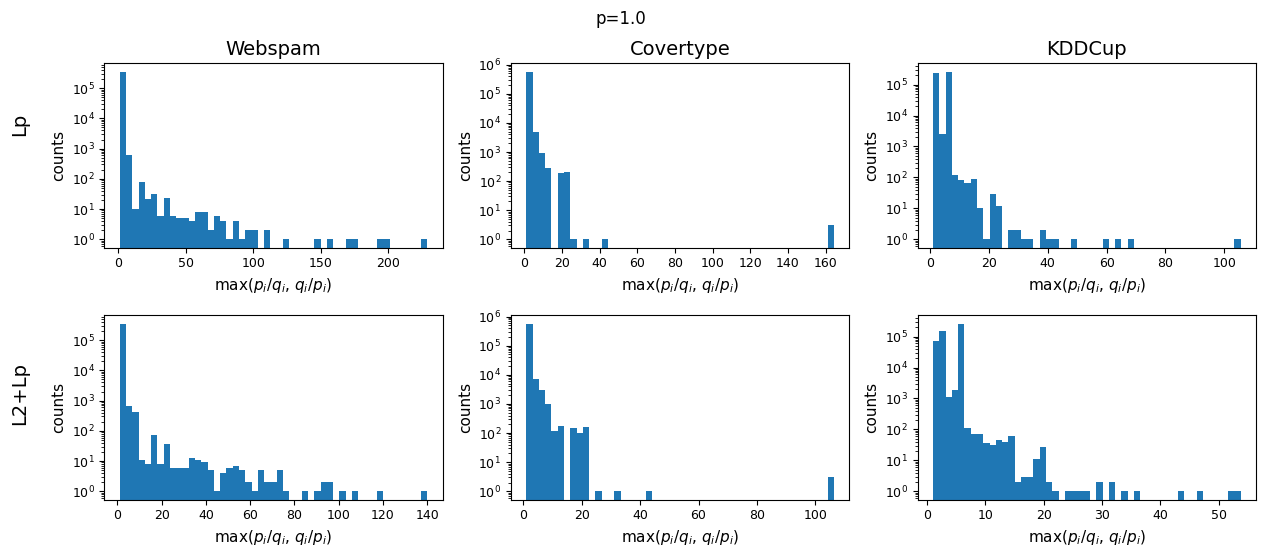

Saved: Plots\Distribution_Comparison\comparison_distributions_p1.0.png


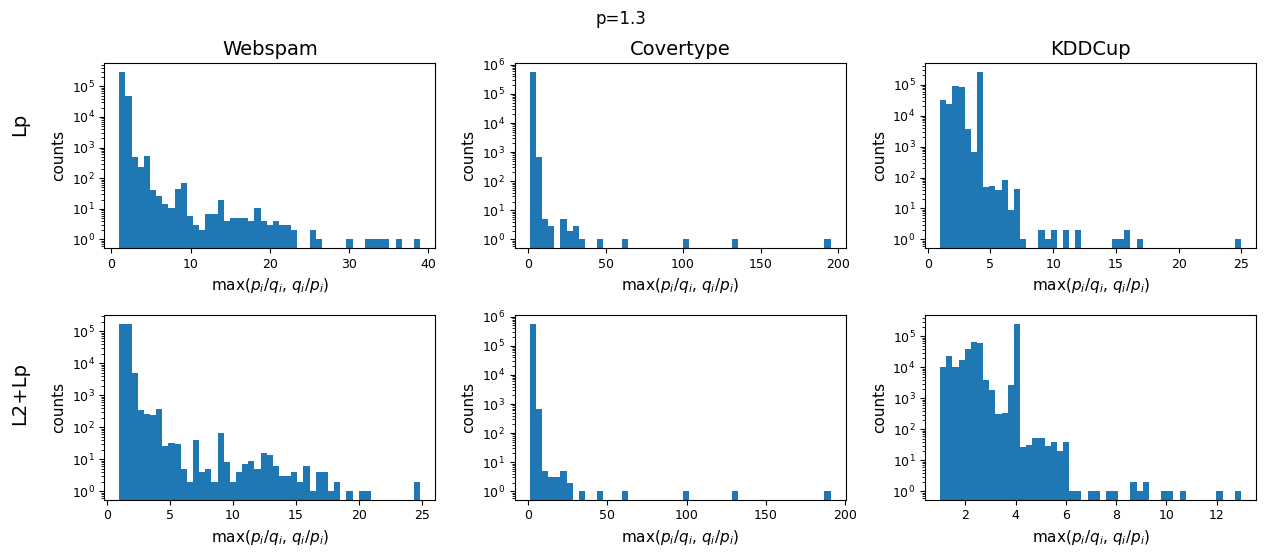

Saved: Plots\Distribution_Comparison\comparison_distributions_p1.3.png


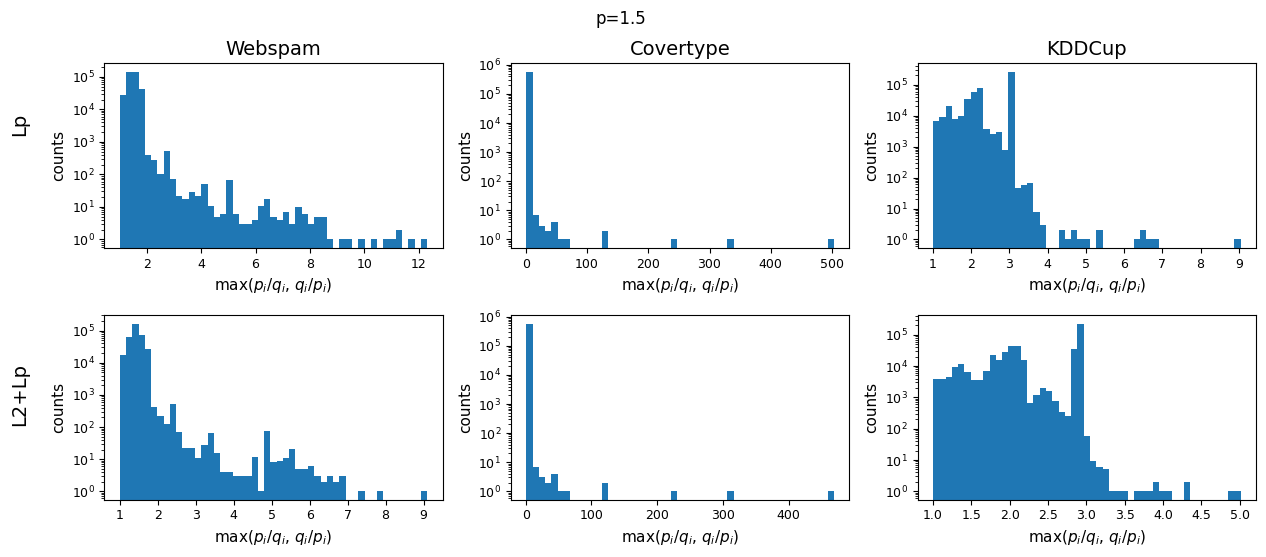

Saved: Plots\Distribution_Comparison\comparison_distributions_p1.5.png


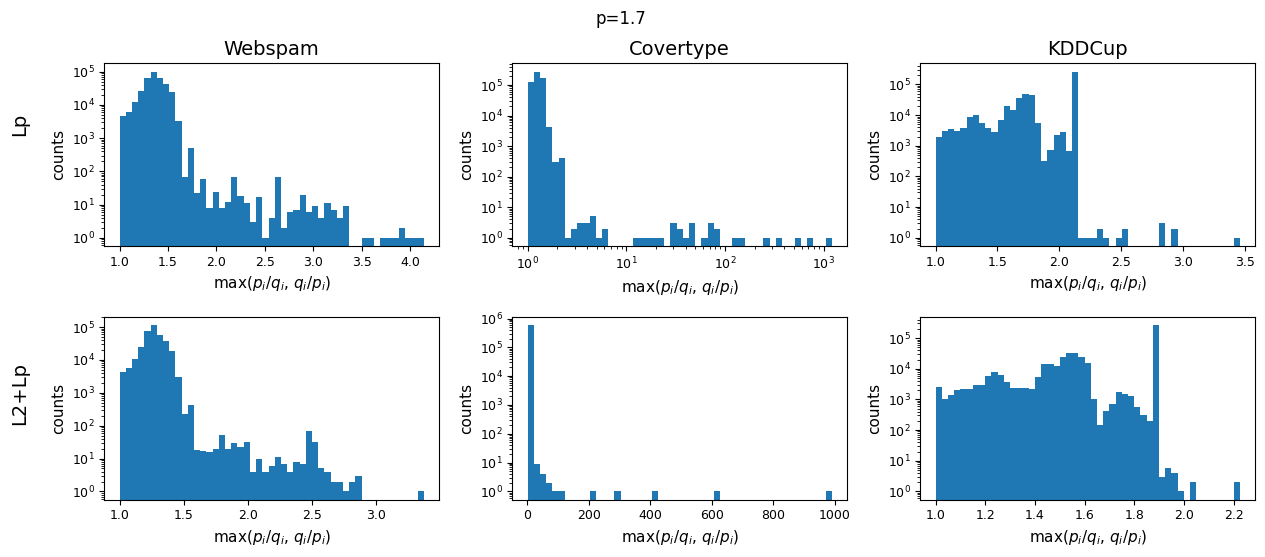

Saved: Plots\Distribution_Comparison\comparison_distributions_p1.7.png


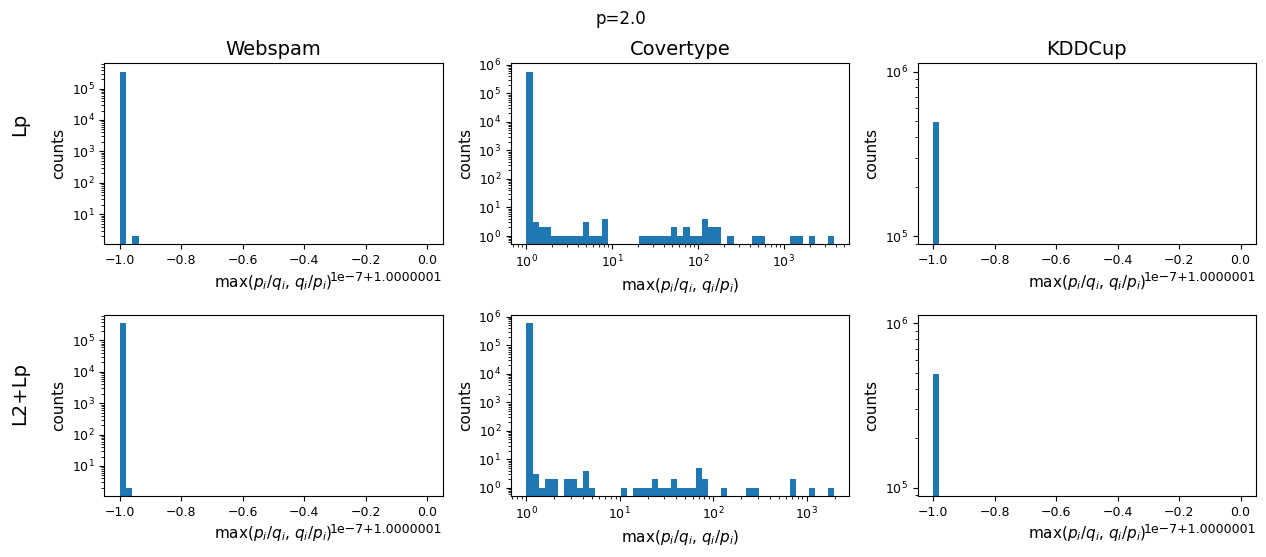

Saved: Plots\Distribution_Comparison\comparison_distributions_p2.0.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from efficient_probit_regression.sampling import compute_leverage_scores, calculate_lewis_weights_exact, calculate_l2_lp_leverage_score, to_density

plt.style.use("default")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9

p = [1.0, 1.3, 1.5, 1.7, 2.0]

out_dir = Path("Plots") / "Distribution_Comparison"
out_dir.mkdir(parents=True, exist_ok=True)

# Datensätze laden
%store -r Webspam
%store -r Covertype
%store -r KDDCup

datasets = {
    "Webspam": Webspam,
    "Covertype": Covertype,
    "KDDCup": KDDCup,
}

def choose_bins_and_xscale(r, n_bins=50):
    r = r[np.isfinite(r)]
    rmax = float(np.max(r)) if r.size else 1.0
    rmax = max(rmax, 1.0000001)
    # Wenn sehr große Spannweite: log-bins + log-x
    if rmax > 1e3:
        bins = np.logspace(0, np.log10(rmax), n_bins)
        xscale = "log"
    else:
        bins = np.linspace(1.0, rmax, n_bins)
        xscale = "linear"
    return bins, xscale

# Plot: 2 Zeilen (lp, l2+lp) x 3 Spalten (Datasets)

for p_param in p:
    fig, axes = plt.subplots(2, 3, figsize=(13, 6))

    for col, (ds_title, ds_obj) in enumerate(datasets.items()):
        X = ds_obj.X

        # q = Lewis weights -> density
        lewis_w = calculate_lewis_weights_exact(X, p=p_param, T=20)
        q = to_density(lewis_w)

        # p1 = lp leverage -> density
        lp_scores = compute_leverage_scores(X, p=p_param, fast_approx=False)
        p1 = to_density(lp_scores)

        # p2 = (l2 + lp) leverage -> density
        l2lp_scores, _ = calculate_l2_lp_leverage_score(X, p=p_param, fast_approx=False)
        p2 = to_density(l2lp_scores)

        # Ratios
        r_lp = np.maximum(p1 / q, q / p1)
        r_l2lp = np.maximum(p2 / q, q / p2)

        # Row 0: lp vs lewis
        ax = axes[0, col]
        bins, xscale = choose_bins_and_xscale(r_lp)
        ax.hist(r_lp, bins=bins)
        ax.set_yscale("log")
        ax.set_xscale(xscale)
        ax.set_title(ds_title)
        ax.set_xlabel(r"max($p_i/q_i$, $q_i/p_i$)")
        ax.set_ylabel("counts")

        # Row 1: l2+lp vs lewis
        ax = axes[1, col]
        bins, xscale = choose_bins_and_xscale(r_l2lp)
        ax.hist(r_l2lp, bins=bins)
        ax.set_yscale("log")
        ax.set_xscale(xscale)
        ax.set_xlabel(r"max($p_i/q_i$, $q_i/p_i$)")
        ax.set_ylabel("counts")

    # Row labels links
    fig.text(0.03, 0.73, "Lp", rotation=90, va="center", fontsize=14)
    fig.text(0.03, 0.28, "L2+Lp", rotation=90, va="center", fontsize=14)

    fig.suptitle(f"p={p_param}", y=0.92)
    fig.tight_layout(rect=[0.05, 0.0, 1.0, 0.95])

    out_path = out_dir / f"comparison_distributions_p{p_param}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved:", out_path)